In [21]:
!pip install tensorflow opencv-python kagglehub

In [22]:
from tensorflow.keras.applications import ResNet50

In [23]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("astraszab/facial-expression-dataset-image-folders-fer2013")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/astraszab/facial-expression-dataset-image-folders-fer2013/versions/1


In [24]:
import os
# num_classes=7
# img_rows,img_cols=48,48
# batch_size=32
num_classes = 7
img_size = 224
batch_size = 32
train_data_dir=os.path.join(path, 'data', 'train')
validation_data_dir=os.path.join(path, 'data', 'val')
test_data_dir = os.path.join(path,'data','test')


In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    shear_range=0.3,
    zoom_range=0.3,
    width_shift_range=0.4,
    height_shift_range=0.4,
    horizontal_flip=True,
    fill_mode='nearest'
)
validation_datagen=ImageDataGenerator(rescale=1./255)

In [26]:
train_generator=train_datagen.flow_from_directory(
    train_data_dir,
    color_mode='rgb',
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

Found 28709 images belonging to 7 classes.


In [27]:
val_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

Found 3589 images belonging to 7 classes.


In [28]:
test_generator = validation_datagen.flow_from_directory(
    test_data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3589 images belonging to 7 classes.


In [29]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze the layers of the base model to prevent them from being updated during training
base_model.trainable = False

In [30]:
# This cell's content has been merged into the model compilation cell (g9GkERtzOpSk) to fix a NameError.

In [31]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model

# Define the input layer explicitly for the entire model
input_tensor = Input(shape=(224, 224, 3))

# Pass the input tensor through the base_model
x = base_model(input_tensor)

x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(7, activation='softmax')(x)

# Create the new functional model
model = Model(inputs=input_tensor, outputs=predictions)

# Ensure base_model's layers remain non-trainable (already set, but good for clarity)
base_model.trainable = False

# No need for model.build() anymore as the model is fully defined with an Input layer.

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.000001
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True
)

In [33]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,887 (90.98 MB)

 Trainable params: 263,175 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [34]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.2049 - loss: 1.9363

898/898 ━━━━━━━━━━━━━━━━━━━━ 419s 455ms/step - accuracy: 0.2176 - loss: 1.8715 - val_accuracy: 0.1956 - val_loss: 1.8181 - learning_rate: 1.0000e-04
Epoch 2/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 392s 436ms/step - accuracy: 0.2341 - loss: 1.8317 - val_accuracy: 0.1691 - val_loss: 1.8160 - learning_rate: 1.0000e-04
Epoch 3/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.2344 - loss: 1.8281

898/898 ━━━━━━━━━━━━━━━━━━━━ 387s 431ms/step - accuracy: 0.2380 - loss: 1.8245 - val_accuracy: 0.2516 - val_loss: 1.8109 - learning_rate: 1.0000e-04
Epoch 4/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.2418 - loss: 1.8238

898/898 ━━━━━━━━━━━━━━━━━━━━ 385s 429ms/step - accuracy: 0.2421 - loss: 1.8215 - val_accuracy: 0.2533 - val_loss: 1.8111 - learning_rate: 1.0000e-04
Epoch 5/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.2465 - loss: 1.8154

898/898 ━━━━━━━━━━━━━━━━━━━━ 386s 430ms/step - accuracy: 0.2426 - loss: 1.8176 - val_accuracy: 0.2538 - val_loss: 1.8098 - learning_rate: 1.0000e-04
Epoch 6/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 387s 431ms/step - accuracy: 0.2445 - loss: 1.8166 - val_accuracy: 0.2516 - val_loss: 1.8042 - learning_rate: 1.0000e-04
Epoch 7/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 387s 430ms/step - accuracy: 0.2471 - loss: 1.8124 - val_accuracy: 0.2516 - val_loss: 1.8040 - learning_rate: 1.0000e-04
Epoch 8/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 385s 428ms/step - accuracy: 0.2480 - loss: 1.8131 - val_accuracy: 0.2538 - val_loss: 1.8043 - learning_rate: 1.0000e-04
Epoch 9/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 386s 429ms/step - accuracy: 0.2491 - loss: 1.8109 - val_accuracy: 0.2516 - val_loss: 1.8113 - learning_rate: 1.0000e-04
Epoch 10/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.2496 - loss: 1.8129

898/898 ━━━━━━━━━━━━━━━━━━━━ 389s 433ms/step - accuracy: 0.2470 - loss: 1.8120 - val_accuracy: 0.2544 - val_loss: 1.8018 - learning_rate: 1.0000e-04
Epoch 11/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 387s 431ms/step - accuracy: 0.2493 - loss: 1.8098 - val_accuracy: 0.2524 - val_loss: 1.8001 - learning_rate: 1.0000e-04
Epoch 12/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 386s 430ms/step - accuracy: 0.2497 - loss: 1.8107 - val_accuracy: 0.2541 - val_loss: 1.8029 - learning_rate: 1.0000e-04
Epoch 13/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.2494 - loss: 1.8081

898/898 ━━━━━━━━━━━━━━━━━━━━ 386s 430ms/step - accuracy: 0.2496 - loss: 1.8081 - val_accuracy: 0.2547 - val_loss: 1.7991 - learning_rate: 1.0000e-04
Epoch 14/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 409s 455ms/step - accuracy: 0.2503 - loss: 1.8078 - val_accuracy: 0.2524 - val_loss: 1.7992 - learning_rate: 1.0000e-04
Epoch 15/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 383s 427ms/step - accuracy: 0.2513 - loss: 1.8073 - val_accuracy: 0.2536 - val_loss: 1.7972 - learning_rate: 1.0000e-04
Epoch 16/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 384s 427ms/step - accuracy: 0.2519 - loss: 1.8075 - val_accuracy: 0.2538 - val_loss: 1.7986 - learning_rate: 1.0000e-04
Epoch 17/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 382s 426ms/step - accuracy: 0.2518 - loss: 1.8041 - val_accuracy: 0.2527 - val_loss: 1.7941 - learning_rate: 1.0000e-04
Epoch 18/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 385s 428ms/step - accuracy: 0.2510 - loss: 1.8056 - val_accuracy: 0.2544 - val_loss: 1.7957 - learning_rate: 1.0000e-04
Epoch 19/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 384s 

898/898 ━━━━━━━━━━━━━━━━━━━━ 387s 431ms/step - accuracy: 0.2516 - loss: 1.8061 - val_accuracy: 0.2566 - val_loss: 1.8036 - learning_rate: 1.0000e-04


In [35]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)

113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.2502 - loss: 1.7976
Test Accuracy: 0.2502089738845825


In [36]:
model.save("emotion_model.h5")

In [37]:
loss, accuracy = model.evaluate(val_generator)

print("Validation Accuracy:", accuracy)

113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.2527 - loss: 1.7941
Validation Accuracy: 0.25271663069725037


In [38]:
import cv2
import numpy as np

In [39]:
emotion_labels = [
    'Angry',
    'Disgust',
    'Fear',
    'Happy',
    'Neutral',
    'Sad',
    'Surprise'
]

In [100]:
img = cv2.imread('/content/radiant-monochrome-joy-stockcake.webp') # Changed to a generic filename and fixed path separator issue. You will need to upload 'test.jpg' or provide its correct path in Colab.

In [101]:
import numpy as np
if img is None:
    print("Error: 'test.jpg' could not be loaded. Please ensure the image file exists and the path is correct.")
    # Create a black dummy image to prevent further NameErrors
    gray = np.zeros((224, 224), dtype=np.uint8)
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [102]:
face_classifier = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    'haarcascade_frontalface_default.xml'
)

In [103]:
faces = face_classifier.detectMultiScale(
    gray,
    scaleFactor=1.3,
    minNeighbors=5
)

In [104]:
for (x,y,w,h) in faces:

    roi_gray = gray[y:y+h, x:x+w]

    roi_gray = cv2.resize(roi_gray, (224,224))

    roi = roi_gray.astype('float') / 255.0

    roi = np.stack((roi,)*3, axis=-1)

    roi = np.expand_dims(roi, axis=0)

    prediction = model.predict(roi)

    label = emotion_labels[np.argmax(prediction)]

    print("Predicted Emotion:", label)

    cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)

    cv2.putText(
        img,
        label,
        (x,y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0,255,0),
        2
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted Emotion: Happy


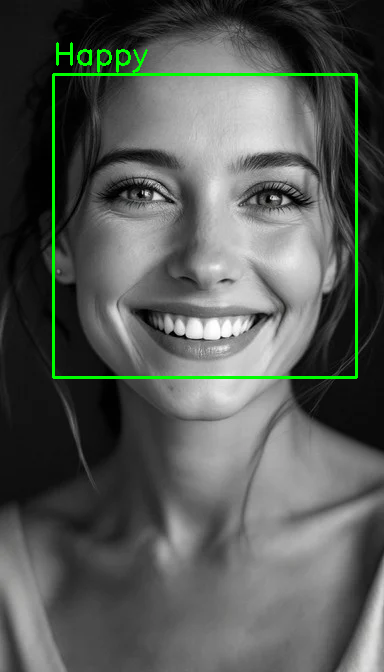

In [105]:
from google.colab.patches import cv2_imshow
cv2_imshow(img)
